In [ ]:
# UCI Adult / Census Income Dataset
# Goal: Predict whether annual income is >50K or <=50K.
# This project follows:
# Load → Inspect → Clean → EDA → Preprocess → Train → Evaluate



In [8]:
import pandas as pd
df=pd.read_csv("adult.data",header=None)

In [9]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [11]:
df.shape

(32561, 15)

In [12]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], dtype='int64')

In [14]:
df.columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

In [15]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [16]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [17]:
print(df['workclass'].value_counts())
print(df['occupation'].value_counts())
print(df['native_country'].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64
native_country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106


In [25]:
import numpy as np
df=df.replace(' ?',np.nan)
df.isnull().sum()



age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [27]:
for col in ['workclass','occupation', 'native_country']:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [29]:
df.duplicated().sum()
df.drop_duplicates()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [31]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [34]:
df['age'].describe()
df[df['age']<0]
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [36]:
df['income'].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

In [41]:
dirty_df = df.copy()

dirty_df.loc[10:20, 'age'] = np.nan
dirty_df.loc[30:40, 'workclass'] = np.nan

dirty_df.loc[50:55, 'education'] = ' Bachelors'
dirty_df.loc[56:60, 'education'] = 'bachelors'

dirty_df.loc[70:72, 'age'] = -10
dirty_df.loc[80, 'hours_per_week'] = 200

dirty_df = pd.concat([dirty_df, dirty_df.iloc[100:110]])

In [42]:
dirty_df.isnull().sum()

age               11
workclass         11
fnlwgt             0
education          0
education_num      0
marital_status     0
occupation         0
relationship       0
race               0
sex                0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
income             0
dtype: int64

In [43]:
dirty_df.loc[10:20, 'age']

10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
20   NaN
Name: age, dtype: float64

In [47]:
dirty_df['age'] = dirty_df['age'].fillna(dirty_df['age'].median())
dirty_df['workclass'] = dirty_df['workclass'].fillna(
    dirty_df['workclass'].mode()[0]
)
dirty_df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [48]:
dirty_df.loc[80, 'hours_per_week'] = 200
dirty_df.loc[81, 'age'] = 150
dirty_df.loc[82, 'capital_gain'] = 1000000

In [56]:
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

In [50]:
find_outliers(dirty_df, 'hours_per_week')


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
6,49.0,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
10,37.0,Private,280464,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,80,United-States,>50K
12,37.0,Private,122272,Bachelors,13,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,United-States,<=50K
20,37.0,Private,193524,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32548,65.0,Self-emp-not-inc,99359,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,1086,0,60,United-States,<=50K
32553,32.0,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32559,22.0,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
101,44.0,Private,198282,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,15024,0,60,United-States,>50K


In [57]:
dirty_df.describe()


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32547.000000,3.254700e+04,32547.000000,32547.000000,32547.000000,32547.000000
mean,38.585676,1.897808e+05,10.081789,1110.582573,87.341383,40.446093
std,13.659262,1.055471e+05,2.571657,9233.885595,403.042809,12.377177
min,-10.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178330e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369925e+05,12.000000,0.000000,0.000000,45.000000
max,150.000000,1.484705e+06,16.000000,1000000.000000,4356.000000,200.000000


In [58]:
Q1 = dirty_df['age'].quantile(0.25)
Q3 = dirty_df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("Lower:", lower)
print("Upper:", upper)

Q1: 28.0
Q3: 48.0
Lower: -2.0
Upper: 78.0


In [59]:
dirty_df['age'].describe()

count    32547.000000
mean        38.585676
std         13.659262
min        -10.000000
25%         28.000000
50%         37.000000
75%         48.000000
max        150.000000
Name: age, dtype: float64

In [63]:
outliers = find_outliers(dirty_df, 'age')
dirty_df = dirty_df.drop(outliers.index)
dirty_df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32302.000000,3.230200e+04,32302.000000,32302.000000,32302.000000,32302.000000
mean,38.270602,1.899737e+05,10.087332,1107.881958,87.237168,40.551421
std,13.180063,1.056584e+05,2.562253,9246.488814,401.923792,12.284485
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178668e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.785755e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.373695e+05,12.000000,0.000000,0.000000,45.000000
max,75.000000,1.484705e+06,16.000000,1000000.000000,4356.000000,200.000000


In [65]:
for col in ['age', 'capital_gain', 'hours_per_week']:
    outliers = find_outliers(dirty_df, col)
    dirty_df = dirty_df.drop(outliers.index)
dirty_df[['age', 'capital_gain', 'hours_per_week']].describe()

,age,capital_gain,hours_per_week
count,14040.000000,14040.0,14040.0
mean,38.086396,0.0,40.0
std,12.238181,0.0,0.0
min,17.000000,0.0,40.0
25%,28.000000,0.0,40.0
50%,37.000000,0.0,40.0
75%,47.000000,0.0,40.0
max,75.000000,0.0,40.0


In [74]:
import numpy as np
dirty_df = df.copy()
dirty_df.loc[10:20, 'age'] = np.nan
dirty_df.loc[30:40, 'workclass'] = np.nan

dirty_df.loc[50:55, 'education'] = ' Bachelors'
dirty_df.loc[56:60, 'education'] = 'bachelors'

dirty_df.loc[70:72, 'age'] = -10
dirty_df.loc[80, 'hours_per_week'] = 200
dirty_df.loc[81, 'age'] = 150
dirty_df.loc[82, 'capital_gain'] = 1000000

dirty_df = pd.concat([dirty_df, dirty_df.iloc[100:110]])

In [75]:
dirty_df['education'].value_counts()

education
 HS-grad         10494
 Some-college     7281
 Bachelors        5358
 Masters          1724
 Assoc-voc        1381
 11th             1176
 Assoc-acdm       1067
 10th              934
 7th-8th           645
 Prof-school       575
 9th               514
 12th              433
 Doctorate         413
 5th-6th           331
 1st-4th           166
 Preschool          50
bachelors            5
Name: count, dtype: int64

In [77]:
dirty_df['education'].unique()
df[col].value_counts()


hours_per_week
40    15204
50     2817
45     1823
60     1475
35     1296
      ...  
87        1
82        1
94        1
92        1
74        1
Name: count, Length: 94, dtype: int64

In [78]:
dirty_df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32536.000000,3.254700e+04,32547.000000,32547.000000,32547.000000,32547.000000
mean,38.586212,1.897808e+05,10.081789,1110.582573,87.341383,40.446093
std,13.661539,1.055471e+05,2.571657,9233.885595,403.042809,12.377177
min,-10.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178330e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369925e+05,12.000000,0.000000,0.000000,45.000000
max,150.000000,1.484705e+06,16.000000,1000000.000000,4356.000000,200.000000


In [79]:
for col in ['age', 'capital_gain', 'hours_per_week']:
    outliers = find_outliers(dirty_df, col)
    print(col, "→", len(outliers), "potential outliers")

age → 146 potential outliers
capital_gain → 2716 potential outliers
hours_per_week → 9004 potential outliers


In [80]:
for col in ['age', 'capital_gain', 'hours_per_week']:
    outliers = find_outliers(dirty_df, col)
    print("\n", col)
    print(outliers[[col]].sort_values(by=col).head(10))
    print(outliers[[col]].sort_values(by=col).tail(10))


 age
        age
70    -10.0
71    -10.0
72    -10.0
74     79.0
6173   79.0
6000   79.0
4720   79.0
3338   79.0
11099  79.0
11532  79.0
         age
15892   90.0
18725   90.0
18277   90.0
18413   90.0
18832   90.0
31696   90.0
31030   90.0
28463   90.0
32277   90.0
81     150.0

 capital_gain
       capital_gain
27275           114
4716            114
23633           114
19855           114
22815           114
6271            114
2592            401
11731           401
19319           594
27491           594
       capital_gain
1482          99999
22811         99999
24105         99999
1246          99999
31828         99999
31972         99999
24983         99999
24067         99999
25178         99999
82          1000000

 hours_per_week
       hours_per_week
32525               1
19750               1
5590                1
1262                1
29752               1
5632                1
20072               1
23536               1
1036                1
25078               1
     

In [ ]:
dirty_df = df.copy()

dirty_df.loc[10:20, 'age'] = np.nan
dirty_df.loc[30:40, 'workclass'] = np.nan

dirty_df.loc[50:55, 'education'] = ' Bachelors'
dirty_df.loc[56:60, 'education'] = 'bachelors'

dirty_df.loc[70:72, 'age'] = -10
dirty_df.loc[80, 'hours_per_week'] = 200
dirty_df.loc[81, 'age'] = 150
dirty_df.loc[82, 'capital_gain'] = 1000000

dirty_df = pd.concat([dirty_df, dirty_df.iloc[100:110]])

In [81]:
# Function to find potential outliers using IQR
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers


# Check potential outliers in numerical columns
for col in ['age', 'capital_gain', 'hours_per_week']:
    
    outliers = find_outliers(dirty_df, col)

    print("\nColumn:", col)
    print("Number of potential outliers:", len(outliers))

    if len(outliers) > 0:
        print("Smallest values:")
        print(outliers[col].sort_values().head(5).to_list())

        print("Largest values:")
        print(outliers[col].sort_values().tail(5).to_list())


Column: age
Number of potential outliers: 146
Smallest values:
[-10.0, -10.0, -10.0, 79.0, 79.0]
Largest values:
[90.0, 90.0, 90.0, 90.0, 150.0]

Column: capital_gain
Number of potential outliers: 2716
Smallest values:
[114, 114, 114, 114, 114]
Largest values:
[99999, 99999, 99999, 99999, 1000000]

Column: hours_per_week
Number of potential outliers: 9004
Smallest values:
[1, 1, 1, 1, 1]
Largest values:
[99, 99, 99, 99, 200]


In [82]:
dirty_df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32536.000000,3.254700e+04,32547.000000,32547.000000,32547.000000,32547.000000
mean,38.586212,1.897808e+05,10.081789,1110.582573,87.341383,40.446093
std,13.661539,1.055471e+05,2.571657,9233.885595,403.042809,12.377177
min,-10.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178330e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369925e+05,12.000000,0.000000,0.000000,45.000000
max,150.000000,1.484705e+06,16.000000,1000000.000000,4356.000000,200.000000


In [86]:
dirty_df = dirty_df[
    (dirty_df['age'] >= 17) &
    (dirty_df['age'] <= 100) &
    (dirty_df['hours_per_week'] <= 168)&
    (dirty_df['capital_gain'] != 1000000)

]

In [87]:
dirty_df[['age', 'hours_per_week', 'capital_gain']].describe()


,age,hours_per_week,capital_gain
count,32530.000000,32530.000000,32530.000000
mean,38.587673,40.438426,1080.422103
std,13.640310,12.344708,7391.490520
min,17.000000,1.000000,0.000000
25%,28.000000,40.000000,0.000000
50%,37.000000,40.000000,0.000000
75%,48.000000,45.000000,0.000000
max,90.000000,99.000000,99999.000000


In [85]:
dirty_df['education'] = dirty_df['education'].str.strip().str.lower()

In [88]:
# Final cleaning check

print("Missing values:")
print(dirty_df.isnull().sum())

print("\nDuplicate rows:")
print(dirty_df.duplicated().sum())

print("\nEducation categories:")
print(dirty_df['education'].value_counts().head(10))

print("\nShape:")
print(dirty_df.shape)

print("\nNumerical summary:")
print(dirty_df.describe())

Missing values:
age                0
workclass         11
fnlwgt             0
education          0
education_num      0
marital_status     0
occupation         0
relationship       0
race               0
sex                0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
income             0
dtype: int64

Duplicate rows:
10

Education categories:
education
hs-grad         10490
some-college     7279
bachelors        5358
masters          1723
assoc-voc        1380
11th             1175
assoc-acdm       1066
10th              934
7th-8th           644
prof-school       575
Name: count, dtype: int64

Shape:
(32530, 15)

Numerical summary:
                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32530.000000  3.253000e+04   32530.000000  32530.000000  32530.000000   
mean      38.587673  1.897772e+05      10.081371   1080.422103     87.387027   
std       13.640310  1.055492e+05       2.571440   7391.490520    403.143165 

In [98]:
# Fill remaining missing workclass values
dirty_df['workclass'] = dirty_df['workclass'].fillna(
    dirty_df['workclass'].mode()[0]
)

# Actually remove duplicate rows
dirty_df = dirty_df.drop_duplicates()

# Verify
print("Missing values:", dirty_df.isnull().sum().sum())
print("Duplicate rows:", dirty_df.duplicated().sum())
print("Final shape:", dirty_df.shape)

Missing values: 0
Duplicate rows: 0
Final shape: (32520, 15)


income
<=50K    24687
>50K      7833
Name: count, dtype: int64


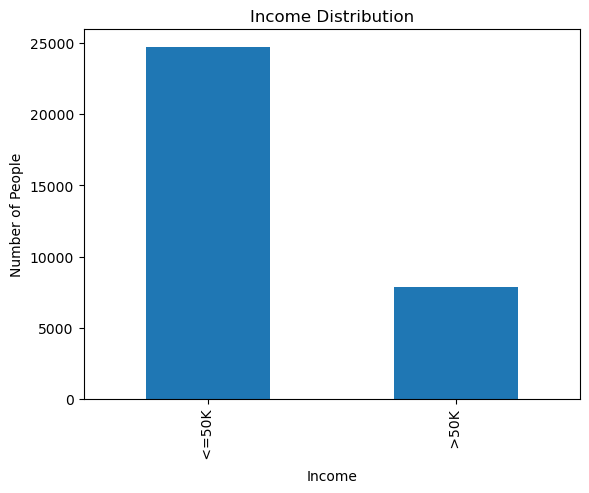

In [99]:
print(dirty_df['income'].value_counts())
import matplotlib.pyplot as plt

dirty_df['income'].value_counts().plot(kind='bar')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.show()
      

In [100]:
pd.crosstab(dirty_df['education'], dirty_df['income'])

income,<=50K,>50K
education,,
10th,871,62
11th,1114,60
12th,400,33
1st-4th,160,6
5th-6th,315,16
7th-8th,604,40
9th,487,27
assoc-acdm,801,265
assoc-voc,1020,360


In [101]:
dirty_df.groupby('income')['age'].mean()

income
<=50K    36.789606
>50K     44.256862
Name: age, dtype: float64

In [102]:
dirty_df.groupby('income')['hours_per_week'].mean()

income
<=50K    38.842670
>50K     45.465467
Name: hours_per_week, dtype: float64

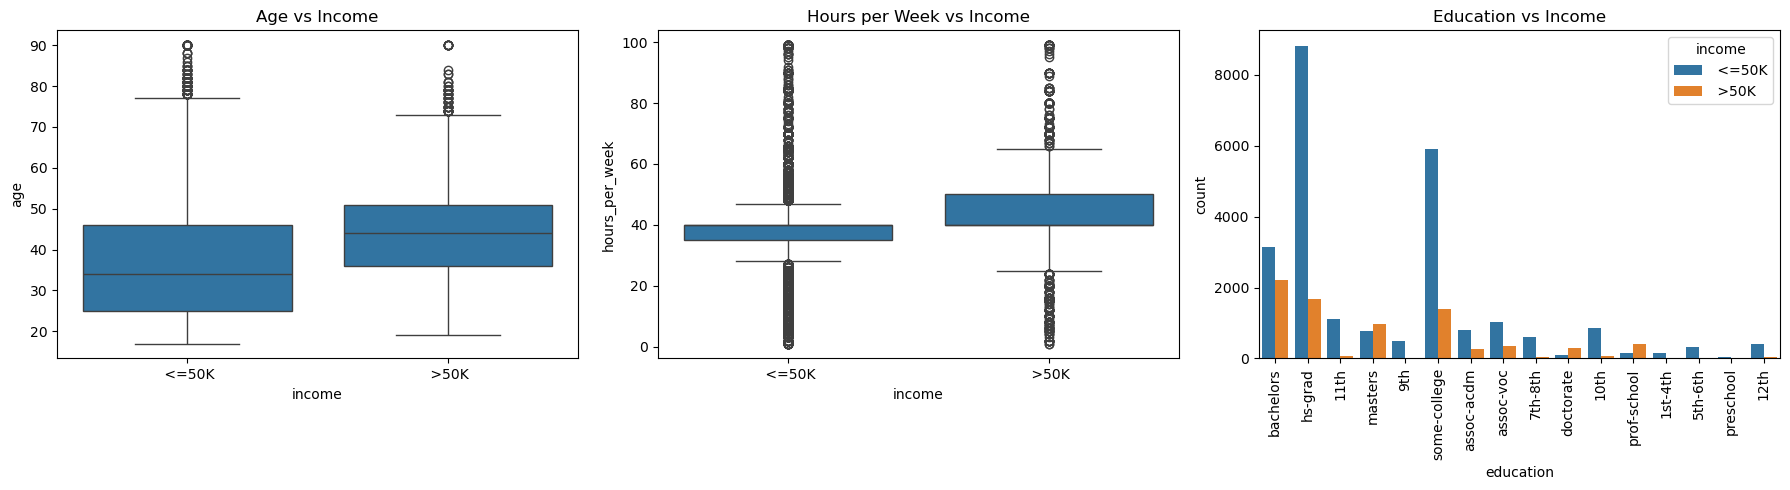

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=dirty_df, x='income', y='age', ax=axes[0])
axes[0].set_title('Age vs Income')

sns.boxplot(data=dirty_df, x='income', y='hours_per_week', ax=axes[1])
axes[1].set_title('Hours per Week vs Income')

sns.countplot(data=dirty_df, x='education', hue='income', ax=axes[2])
axes[2].tick_params(axis='x', rotation=90)
axes[2].set_title('Education vs Income')

plt.tight_layout()
plt.show()

In [104]:
# ==========================================
# 1. Separate Features and Target
# ==========================================

X = dirty_df.drop('income', axis=1)
y = dirty_df['income'].str.strip().map({
    '<=50K': 0,
    '>50K': 1
})


# ==========================================
# 2. Identify categorical and numerical columns
# ==========================================

categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include='number').columns


# ==========================================
# 3. Preprocessing
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


# ==========================================
# 4. Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# 5. Apply preprocessing
# ==========================================

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


# ==========================================
# 6. Build Logistic Regression Model
# ==========================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# ==========================================
# 7. Make Predictions
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 8. Evaluate the Model
# ==========================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8468634686346863

Confusion Matrix:
[[4563  374]
 [ 622  945]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4937
           1       0.72      0.60      0.65      1567

    accuracy                           0.85      6504
   macro avg       0.80      0.76      0.78      6504
weighted avg       0.84      0.85      0.84      6504



In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8517835178351784

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4937
           1       0.72      0.63      0.67      1567

    accuracy                           0.85      6504
   macro avg       0.80      0.78      0.79      6504
weighted avg       0.85      0.85      0.85      6504



In [ ]:


# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. LOAD DATASET
# Why: Load the raw Adult dataset into a DataFrame.
df = pd.read_csv("adult.data", header=None)

df.columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

print(df.head())
print(df.shape)
print(df.dtypes)


# 3. CHECK MISSING VALUES
# Why: Find missing values and hidden '?' values.
print(df.isnull().sum())
print((df == '?').sum())


# 4. CLEAN ORIGINAL MISSING VALUES
# Why: Convert '?' into missing values and fill categorical missing values.
df = df.replace(r'^\s*\?\s*$', pd.NA, regex=True)

for col in ['workclass', 'occupation', 'native_country']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())


# 5. CHECK AND REMOVE ORIGINAL DUPLICATES
# Why: Remove repeated records before creating our dirty dataset.
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after cleaning:", df.duplicated().sum())


# 6. CREATE DIRTY DATA
# Why: Create realistic data-quality problems for cleaning practice.
dirty_df = df.copy()

dirty_df.loc[10:20, 'age'] = np.nan
dirty_df.loc[30:40, 'workclass'] = np.nan

dirty_df.loc[50:55, 'education'] = ' Bachelors'
dirty_df.loc[56:60, 'education'] = 'bachelors'

dirty_df.loc[70:72, 'age'] = -10
dirty_df.loc[80, 'hours_per_week'] = 200
dirty_df.loc[81, 'age'] = 150
dirty_df.loc[82, 'capital_gain'] = 1000000

dirty_df = pd.concat([dirty_df, dirty_df.iloc[100:110]])

print(dirty_df.shape)


# 7. INSPECT NUMERICAL DATA
# Why: Understand the numerical distribution and spot suspicious values.
print(dirty_df.describe())


# 8. IQR OUTLIER DETECTION FUNCTION
# Why: Automatically identify statistically unusual numerical values.
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[column] < lower) |
        (df[column] > upper)
    ]


# 9. FIND POTENTIAL OUTLIERS
# Why: Check how many potential outliers exist without deleting anything.
for col in ['age', 'capital_gain', 'hours_per_week']:
    outliers = find_outliers(dirty_df, col)

    print("\nColumn:", col)
    print("Potential outliers:", len(outliers))

    print("Smallest values:")
    print(outliers[col].sort_values().head(10).to_list())

    print("Largest values:")
    print(outliers[col].sort_values().tail(10).to_list())


# 10. HANDLE MISSING VALUES CREATED IN DIRTY DATA
# Why: Fill missing values so the model does not receive missing data.
dirty_df['age'] = dirty_df['age'].fillna(dirty_df['age'].median())

dirty_df['workclass'] = dirty_df['workclass'].fillna(
    dirty_df['workclass'].mode()[0]
)


# 11. CLEAN INVALID NUMERICAL VALUES
# Why: Remove values that are clearly invalid based on domain knowledge.
dirty_df = dirty_df[
    (dirty_df['age'] >= 17) &
    (dirty_df['age'] <= 100) &
    (dirty_df['hours_per_week'] <= 168) &
    (dirty_df['capital_gain'] != 1000000)
]


# 12. CHECK CATEGORICAL INCONSISTENCY
# Why: Find categories that may represent the same thing in different formats.
print(dirty_df['education'].value_counts())


# 13. STANDARDIZE EDUCATION
# Why: Make equivalent categorical values consistent.
dirty_df['education'] = (
    dirty_df['education']
    .str.strip()
    .str.lower()
)


# 14. REMOVE DUPLICATES CREATED IN DIRTY DATA
# Why: Remove the duplicate records we intentionally added.
dirty_df = dirty_df.drop_duplicates()


# 15. FINAL DATA CLEANING CHECK
# Why: Confirm that the dataset is ready for EDA and modeling.
print("Missing values:", dirty_df.isnull().sum().sum())
print("Duplicate rows:", dirty_df.duplicated().sum())
print("Final shape:", dirty_df.shape)
print(dirty_df.describe())


# ============================================================
# EDA
# ============================================================

# 16. TARGET DISTRIBUTION
# Why: Understand how the income classes are distributed.
print(dirty_df['income'].value_counts())

dirty_df['income'].value_counts().plot(kind='bar')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.show()


# 17. EDUCATION VS INCOME
# Why: Check whether education appears related to income.
print(pd.crosstab(dirty_df['education'], dirty_df['income']))


# 18. AGE VS INCOME
# Why: Compare average age between income groups.
print(dirty_df.groupby('income')['age'].mean())


# 19. HOURS PER WEEK VS INCOME
# Why: Compare average working hours between income groups.
print(dirty_df.groupby('income')['hours_per_week'].mean())


# 20. VISUALIZE EDA RELATIONSHIPS
# Why: Visualizations make relationships easier to understand.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=dirty_df, x='income', y='age', ax=axes[0])
axes[0].set_title('Age vs Income')

sns.boxplot(data=dirty_df, x='income', y='hours_per_week', ax=axes[1])
axes[1].set_title('Hours per Week vs Income')

sns.countplot(data=dirty_df, x='education', hue='income', ax=axes[2])
axes[2].tick_params(axis='x', rotation=90)
axes[2].set_title('Education vs Income')

plt.tight_layout()
plt.show()


# ============================================================
# PREPROCESSING
# ============================================================

# 21. SEPARATE FEATURES AND TARGET
# Why: X contains inputs and y contains the value we want to predict.
X = dirty_df.drop('income', axis=1)

y = dirty_df['income'].str.strip().map({
    '<=50K': 0,
    '>50K': 1
})


# 22. IDENTIFY COLUMN TYPES
# Why: Numerical and categorical columns require different preprocessing.
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include='number').columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))


# 23. CREATE PREPROCESSOR
# Why: Define scaling for numerical data and encoding for categorical data.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

# 24. SPLIT DATA
# Why: Train on one portion and evaluate on unseen test data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


# 25. APPLY PREPROCESSING
# Why: Learn preprocessing rules from training data and apply the same rules to test data.
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


# ============================================================
# LOGISTIC REGRESSION
# ============================================================

# 26. TRAIN LOGISTIC REGRESSION
# Why: Create a baseline model for binary classification.
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# 27. MAKE PREDICTIONS
# Why: Predict income classes for unseen test data.
y_pred = model.predict(X_test)


# 28. EVALUATE LOGISTIC REGRESSION
# Why: Measure how well the model performs.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# RANDOM FOREST
# ============================================================

# 29. TRAIN RANDOM FOREST
# Why: Test a model capable of learning more complex relationships.
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


# 30. RANDOM FOREST PREDICTIONS
# Why: Predict income using the trained Random Forest.
rf_pred = rf_model.predict(X_test)


# 31. EVALUATE RANDOM FOREST
# Why: Compare Random Forest performance with Logistic Regression.
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))